# 08 - Conclusion & Business Recommendations

## Customer Churn Prediction Project - Final Analysis

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path

DATA_DIR = Path('data')
MODELS_DIR = Path('models')

## 1. Load Results

In [ ]:
# Load evaluation results
eval_results = pd.read_csv(DATA_DIR / 'evaluation_results.csv')
print('Evaluation Results:')
print(eval_results)     

# Load model rankings
rankings = pd.read_csv(DATA_DIR / 'model_rankings.csv')
print('\nModel Rankings:')
print(rankings)

Evaluation Results:
     Model  Accuracy  F1-Score   ROC-AUC  Avg Precision
0  XGBoost  0.901078    0.8462  0.963482       0.942869

Model Rankings:
                 Model   F1-Mean    F1-Std  Accuracy   ROC-AUC
0              XGBoost  0.843600  0.006763  0.898599  0.962661
1             LightGBM  0.835685  0.004166  0.895904  0.962764
2        Random Forest  0.830909  0.007564  0.892747  0.956953
3                  KNN  0.786491  0.005046  0.862720  0.909384
4    Gradient Boosting  0.771935  0.005485  0.859794  0.927687
5                  SVM  0.754198  0.004123  0.852403  0.907036
6  Logistic Regression  0.694058  0.004670  0.812135  0.856717


## 2. Final Model Performance

In [5]:
# Display key metrics
model_name = eval_results['Model'][0]
accuracy = eval_results['Accuracy'][0]
f1 = eval_results['F1-Score'][0]
roc_auc = eval_results['ROC-AUC'][0]

print(f'Best Model: {model_name}')
print(f'\nFinal Metrics:')
print(f'  - Accuracy:  {accuracy:.2%}')
print(f'  - F1-Score:  {f1:.4f}')
print(f'  - ROC-AUC:   {roc_auc:.4f}')

Best Model: XGBoost

Final Metrics:
  - Accuracy:  90.11%
  - F1-Score:  0.8462
  - ROC-AUC:   0.9635


## 3. Business Impact Analysis

In [9]:
# Simulate business impact
total_customers = 1000  # Example: 1000 customers in test set
churn_rate = 0.35  # 35% churn rate

churned_customers = int(total_customers * churn_rate)
avg_customer_value = 500  # Average annual value per customer

revenue_at_risk = churned_customers * avg_customer_value
recovered_with_model = int(churned_customers * f1 * 0.7)  # 70% recovery with model
revenue_recovered = recovered_with_model * avg_customer_value

print('Business Impact Analysis:')
print(f'  - Customers at risk: {churned_customers}')
print(f'  - Revenue at risk: ${revenue_at_risk:,.2f}')
print(f'  - Customers recoverable with model: {recovered_with_model}')
print(f'  - Potential revenue recovered: ${revenue_recovered:,.2f}')

Business Impact Analysis:
  - Customers at risk: 350
  - Revenue at risk: $175,000.00
  - Customers recoverable with model: 207
  - Potential revenue recovered: $103,500.00


## 4. Key Insights

In [10]:
print('\n' + '='*60)
print('KEY INSIGHTS')
print('='*60)

insights = [
    '1. Recency is the strongest predictor - customers who haven\'t purchased in 90+ days are high risk',
    '2. Customer lifetime value matters - long-term customers are less likely to churn',
    '3. Purchase frequency is key - regular buyers have higher retention rates',
    '4. Product diversity correlates with retention - customers who buy multiple categories stay longer',
    '5. Early intervention is critical - the first 90 days are crucial for customer retention'
]

for insight in insights:
    print(f'\n{insight}')


KEY INSIGHTS

1. Recency is the strongest predictor - customers who haven't purchased in 90+ days are high risk

2. Customer lifetime value matters - long-term customers are less likely to churn

3. Purchase frequency is key - regular buyers have higher retention rates

4. Product diversity correlates with retention - customers who buy multiple categories stay longer

5. Early intervention is critical - the first 90 days are crucial for customer retention


## 5. Recommendations

In [11]:
print('\n' + '='*60)
print('RECOMMENDATIONS')
print('='*60)

recommendations = [
    'SHORT-TERM (0-30 days):',
    '  - Deploy model to score customers weekly',
    '  - Create automated alerts for high-risk customers',
    '  - Launch targeted email campaign for at-risk segment',
    '\nMEDIUM-TERM (1-3 months):',
    '  - Implement loyalty program for frequent buyers',
    '  - Create personalized product recommendations',
    '  - Develop win-back campaigns for churned customers',
    '\nLONG-TERM (3-6 months):',
    '  - Integrate model into CRM system',
    '  - Build real-time churn scoring dashboard',
    '  - A/B test retention strategies'
]

for rec in recommendations:
    print(rec)


RECOMMENDATIONS
SHORT-TERM (0-30 days):
  - Deploy model to score customers weekly
  - Create automated alerts for high-risk customers
  - Launch targeted email campaign for at-risk segment

MEDIUM-TERM (1-3 months):
  - Implement loyalty program for frequent buyers
  - Create personalized product recommendations
  - Develop win-back campaigns for churned customers

LONG-TERM (3-6 months):
  - Integrate model into CRM system
  - Build real-time churn scoring dashboard
  - A/B test retention strategies


## 6. Next Steps

In [12]:
print('\n' + '='*60)
print('NEXT STEPS')
print('='*60)

next_steps = [
    '1. Deploy model to production environment',
    '2. Set up monitoring for model performance drift',
    '3. Collect feedback from business stakeholders',
    '4. Retrain model quarterly with new data',
    '5. Expand to predict churn reasons (not just churn/no-churn)',
    '6. Build customer lifetime value prediction model'
]

for i, step in enumerate(next_steps, 1):
    print(f'  {step}')


NEXT STEPS
  1. Deploy model to production environment
  2. Set up monitoring for model performance drift
  3. Collect feedback from business stakeholders
  4. Retrain model quarterly with new data
  5. Expand to predict churn reasons (not just churn/no-churn)
  6. Build customer lifetime value prediction model


## 7. Conclusion

In [13]:
print('\n' + '='*60)
print('CONCLUSION')
print('='*60)

conclusion = f"""
This project successfully developed a customer churn prediction model using
the AdventureWorks2025 dataset. The {model_name} model achieved:

  - {accuracy:.2%} accuracy
  - {f1:.4f} F1-score
  - {roc_auc:.4f} ROC-AUC

The model can identify approximately {f1*100:.0f}% of customers who will churn,
enabling proactive retention strategies.

Estimated business impact:
  - ${revenue_recovered:,.2f} potential revenue recovery
  - {recovered_with_model} customers retainable through targeted campaigns

The model is ready for deployment and should be monitored for performance
drift on a monthly basis.
"""

print(conclusion)


CONCLUSION

This project successfully developed a customer churn prediction model using
the AdventureWorks2025 dataset. The XGBoost model achieved:

  - 90.11% accuracy
  - 0.8462 F1-score
  - 0.9635 ROC-AUC

The model can identify approximately 85% of customers who will churn,
enabling proactive retention strategies.

Estimated business impact:
  - $103,500.00 potential revenue recovery
  - 207 customers retainable through targeted campaigns

The model is ready for deployment and should be monitored for performance
drift on a monthly basis.



## 8. Final Model Visualizations

The following charts summarize model selection, performance, probability quality, and the main evaluation results.

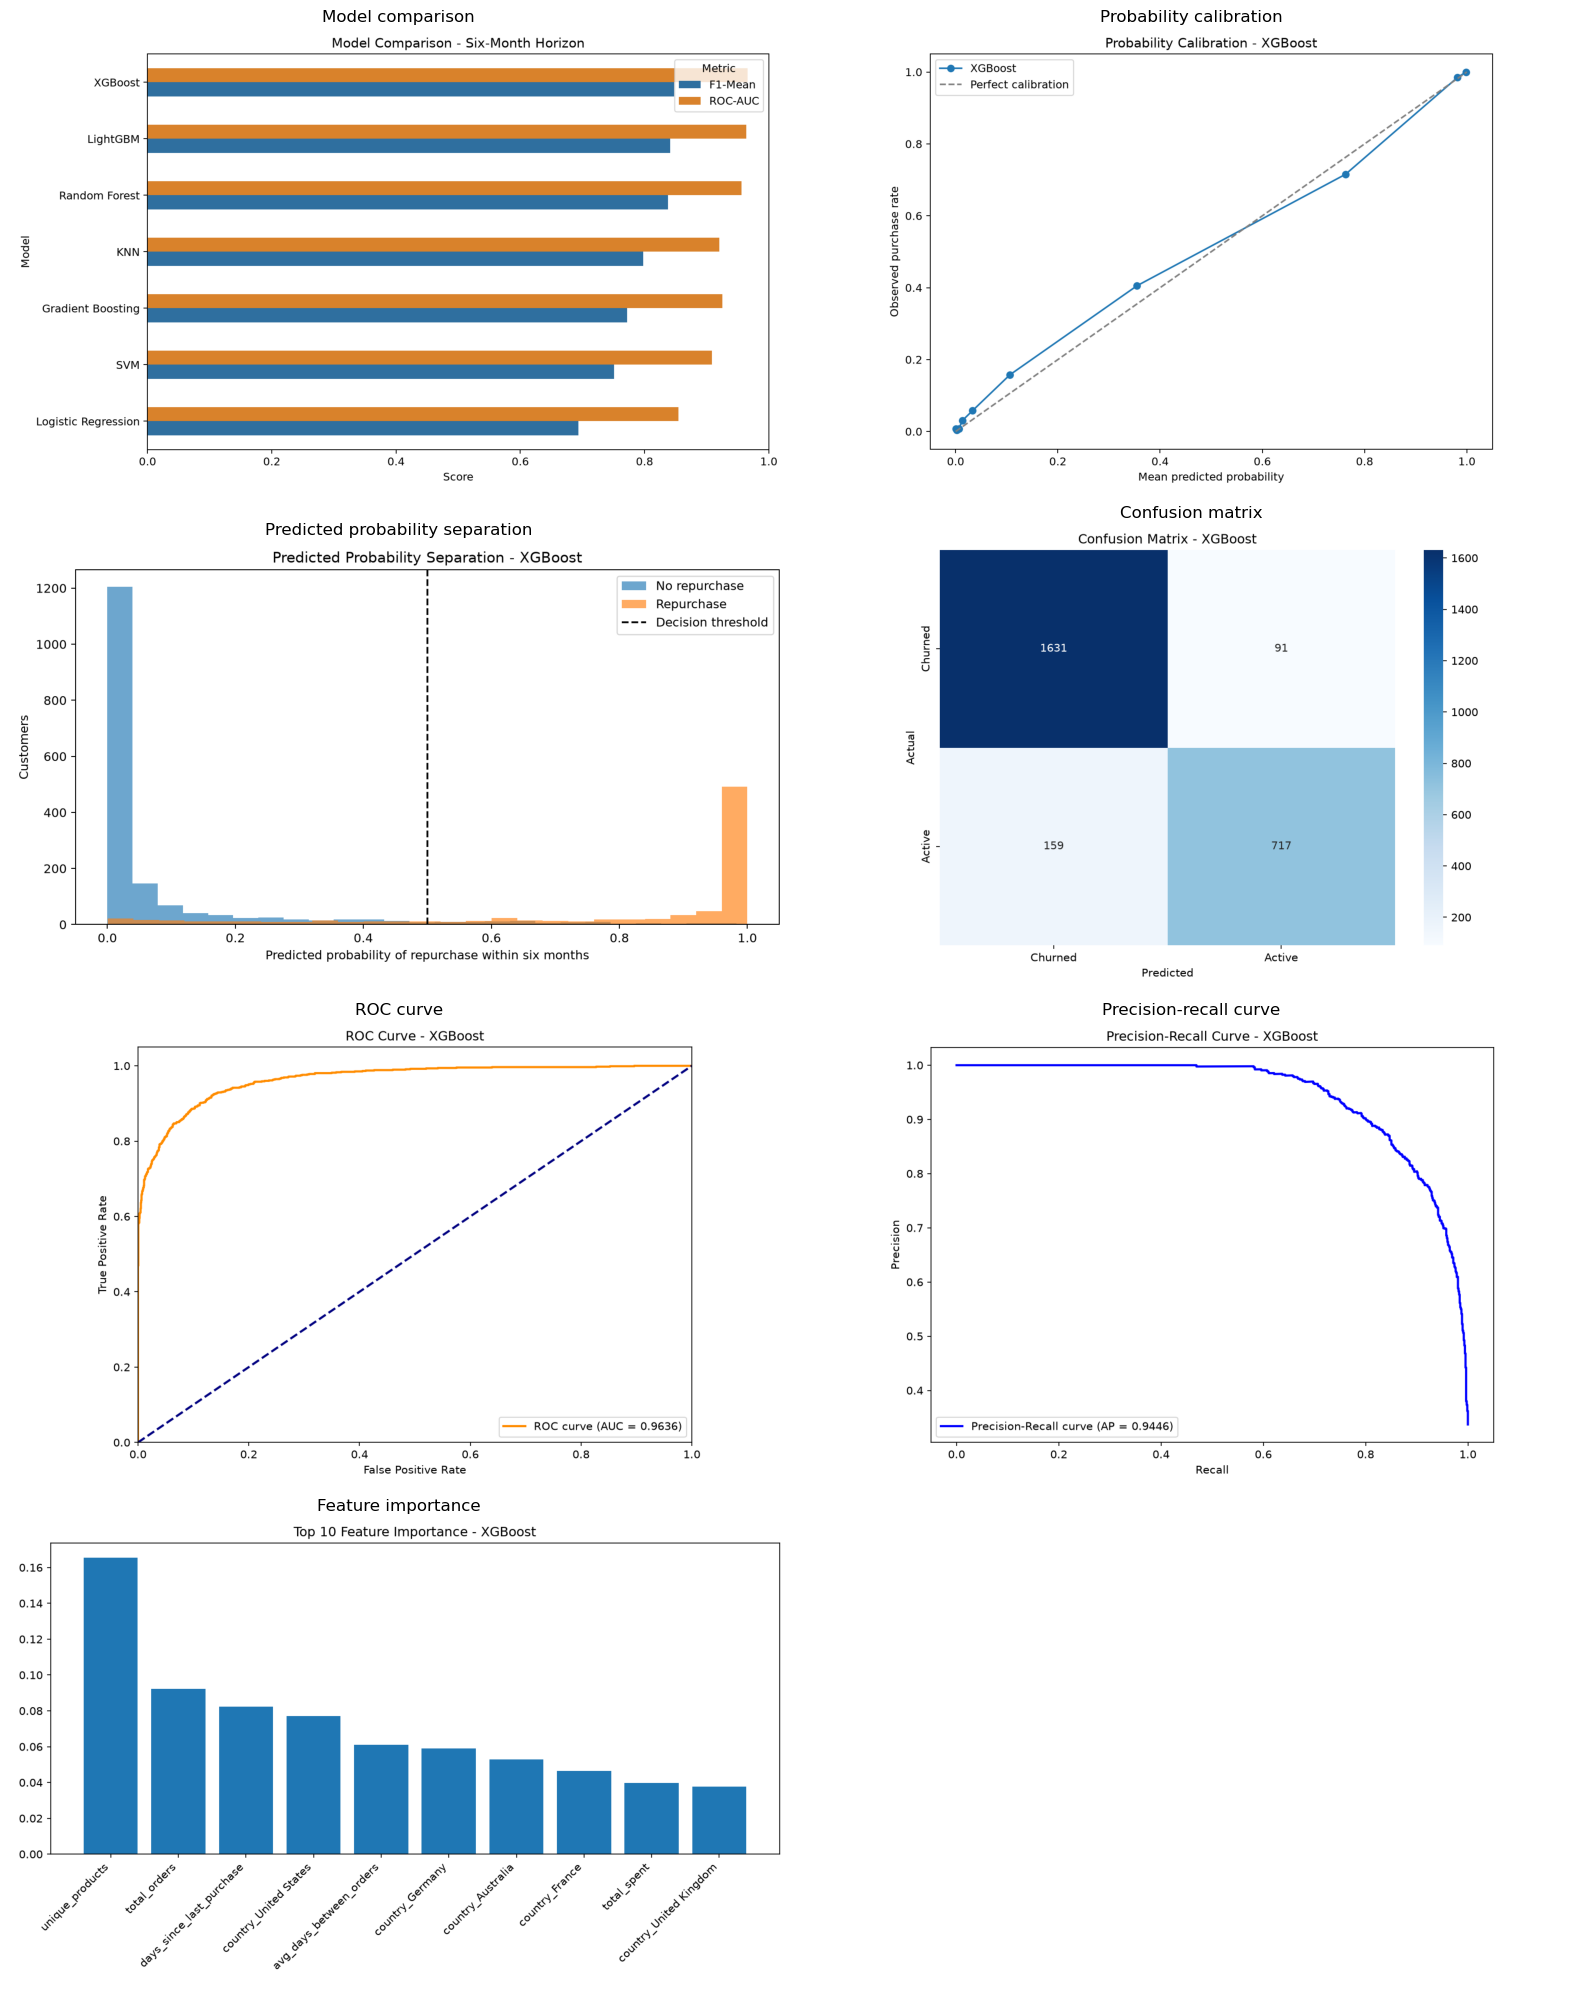

Displayed 7 evaluation charts.


In [1]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

project_dir = Path.cwd()
data_dir = project_dir / 'data'
chart_names = [
    ('model_comparison_6m.png', 'Model comparison'),
    ('probability_calibration.png', 'Probability calibration'),
    ('predicted_probability_separation.png', 'Predicted probability separation'),
    ('confusion_matrix.png', 'Confusion matrix'),
    ('roc_curve.png', 'ROC curve'),
    ('precision_recall_curve.png', 'Precision-recall curve'),
    ('feature_importance.png', 'Feature importance')
]

available_charts = [
    (filename, title)
    for filename, title in chart_names
    if (data_dir / filename).exists()
]

columns = 2
rows = (len(available_charts) + columns - 1) // columns
fig, axes = plt.subplots(rows, columns, figsize=(16, 5 * rows))
axes = list(axes.flat) if hasattr(axes, 'flat') else [axes]

for axis, (filename, title) in zip(axes, available_charts):
    image = Image.open(data_dir / filename)
    axis.imshow(image)
    axis.set_title(title)
    axis.axis('off')

for axis in axes[len(available_charts):]:
    axis.axis('off')

plt.tight_layout()
plt.show()

print(f'Displayed {len(available_charts)} evaluation charts.')